In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df = pd.read_excel(r'Telco_customer_churn.xlsx')
df.head() # Display starting 5 rows

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [119]:
df.shape # Return number of columns and rows

(7043, 33)

In [120]:
df.info() # showing brief structure

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [121]:
df.isnull().sum() # Checking for null values

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [35]:
# Removing columns that are not needed 
df.drop(['Lat Long', 'Count', 'Country', 'State'], axis=1, inplace=True)

In [122]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [8]:
# Filling empty values with 'No Reason!' text in Churn Reason column
df.fillna('No Reason!', inplace=True)

,CustomerID,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,Landers,92285,34.341737,-116.539416,Female,No,No,No,72,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,No Reason!
7039,6840-RESVB,Adelanto,92301,34.667815,-117.536183,Male,No,Yes,Yes,24,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,No Reason!
7040,2234-XADUH,Amboy,92304,34.559882,-115.637164,Female,No,Yes,Yes,72,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,No Reason!
7041,4801-JZAZL,Angelus Oaks,92305,34.167800,-116.864330,Female,No,Yes,Yes,11,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,No Reason!


In [123]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [12]:
df.columns

Index(['CustomerID', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [17]:
df.dtypes

CustomerID               str
City                     str
Zip Code               int64
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

In [70]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [71]:
df['Total Charges'].dtype

dtype('float64')

In [54]:
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges        float64
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

In [37]:
df.columns

Index(['CustomerID', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [38]:
# Checking for duplicate data
df.duplicated().sum()

np.int64(0)

In [41]:
# Checking for duplicate customer id 
df['CustomerID'].duplicated().sum()

np.int64(0)

In [42]:
# Checking unique values Gender columns 
df['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [43]:
# Checking unique values Contract columns
df['Contract'].unique()

<StringArray>
['Month-to-month', 'Two year', 'One year']
Length: 3, dtype: str

In [49]:
# Checking unique values Payment Method columns
df["Payment Method"].unique()

<StringArray>
[             'Mailed check',          'Electronic check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [126]:
# Removing accidental spaces
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].str.strip()

EXPLORATORY DATA ANALYSIS (EDA)

In [56]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df['Churn Label'].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

EXPLORATORY DATA ANALYSE (EDA)
-

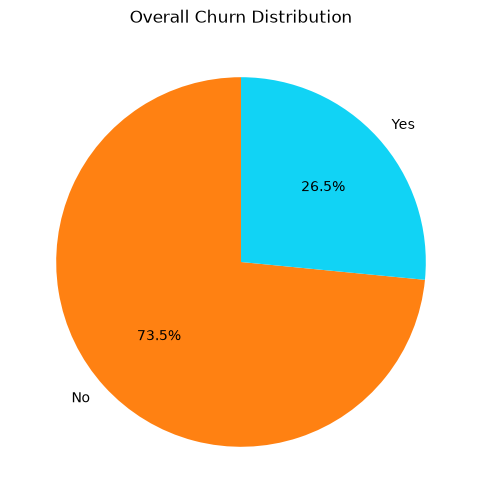

In [12]:
''' VISUALIZING CUSTOMER CHURN DISTRIBUTION '''
churn_per = (df['Churn Label'].value_counts(normalize=True).mul(100))
plt.figure(figsize=(6, 6))
plt.pie(
    churn_per,
    labels = churn_per.index,
    autopct = "%1.1f%%",
    colors = ["#ff8112", "#11d3f5"],
    startangle = 90
)

plt.title("Overall Churn Distribution")
plt.show()

1 in every 4 customers has churned.

Visualizing Tenure
-

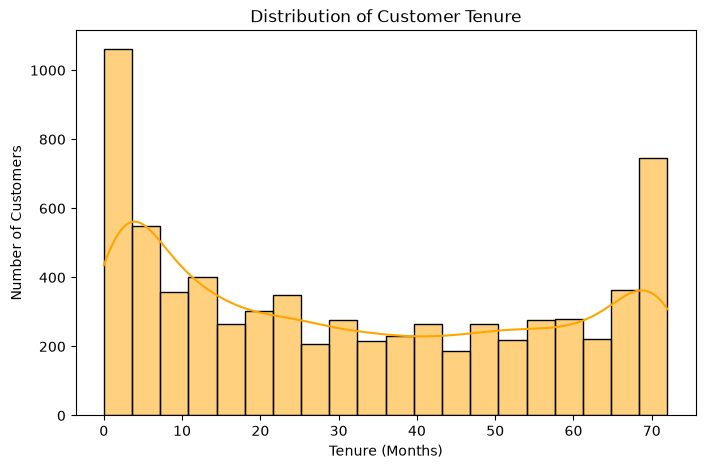

In [11]:
''' Visualizing Tenure '''
plt.figure(figsize=(8, 5))

sns.histplot(
    x = 'Tenure Months',
    data = df,
    bins = 20,
    kde = True,
    color = "Orange"
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

This tells us how long customers typically stay with the company.

Tenure VS Churn
-

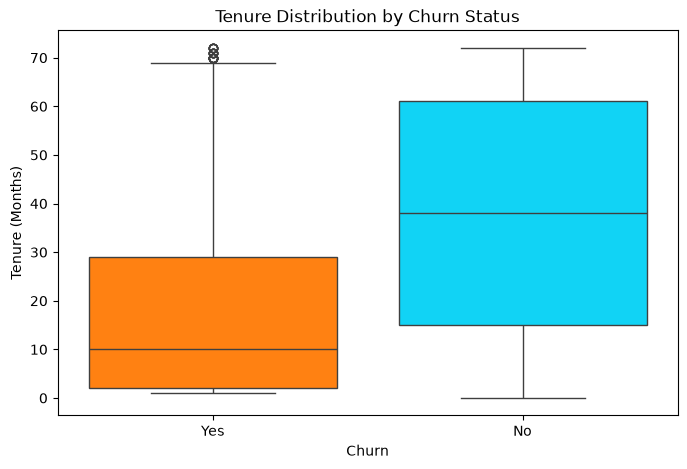

In [8]:
''' Tenure VS Churn '''
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    x = "Churn Label",
    y = "Tenure Months",
    data = df
)

ax.patches[0].set_facecolor("#ff8112")
ax.patches[1].set_facecolor("#11d3f5")

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

Insight: Customers who churn tend to have much shorter relationships with the company.
Stayed      37.57 months and 
Churned     17.98 months

In [131]:
df["Tenure Months"].dtype

dtype('int64')

In [16]:
''' Create Tenure Group '''
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 6, 12, 24, 36, 48, 60, 72],
    labels=[
        "0-6",
        "7-12",
        "13-24",
        "25-36",
        "37-48",
        "49-60",
        "61-72"
    ]
)

In [17]:
tenure_churn = (
    df.groupby("Tenure Group", observed=True)["Churn Label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(tenure_churn)

Tenure Group
0-6      52.937205
7-12     35.886525
13-24    28.710938
25-36    21.634615
37-48    19.028871
49-60    14.423077
61-72     6.609808
Name: Churn Label, dtype: float64


Visualize Tenure Churn
-

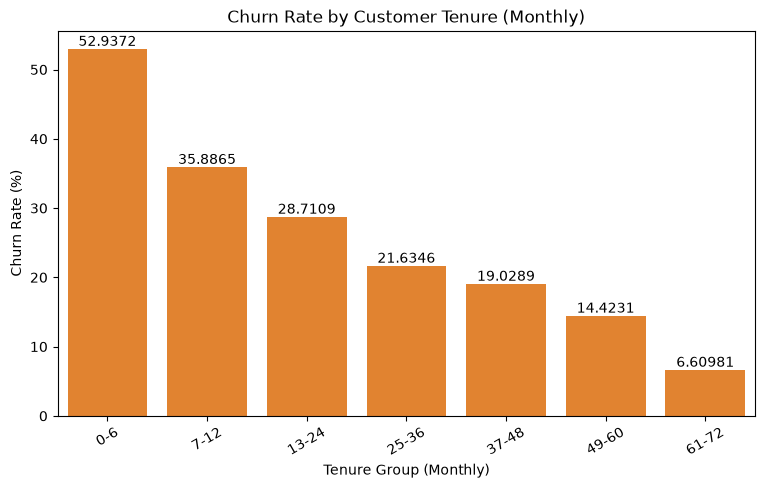

In [19]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x = tenure_churn.index,
    y = tenure_churn.values,
    color = "#ff8112"
)

plt.title("Churn Rate by Customer Tenure (Monthly)")
plt.xlabel("Tenure Group (Monthly)")
plt.ylabel("Churn Rate (%)")

for bars in ax.containers:
    ax.bar_label(bars)

plt.xticks(rotation=30)

plt.show()

Conclusion: The probability of churn decreases substantially as customer tenure increases.

Distribution of Monthly Charges  &
Monthly Charges by Churn Status
-

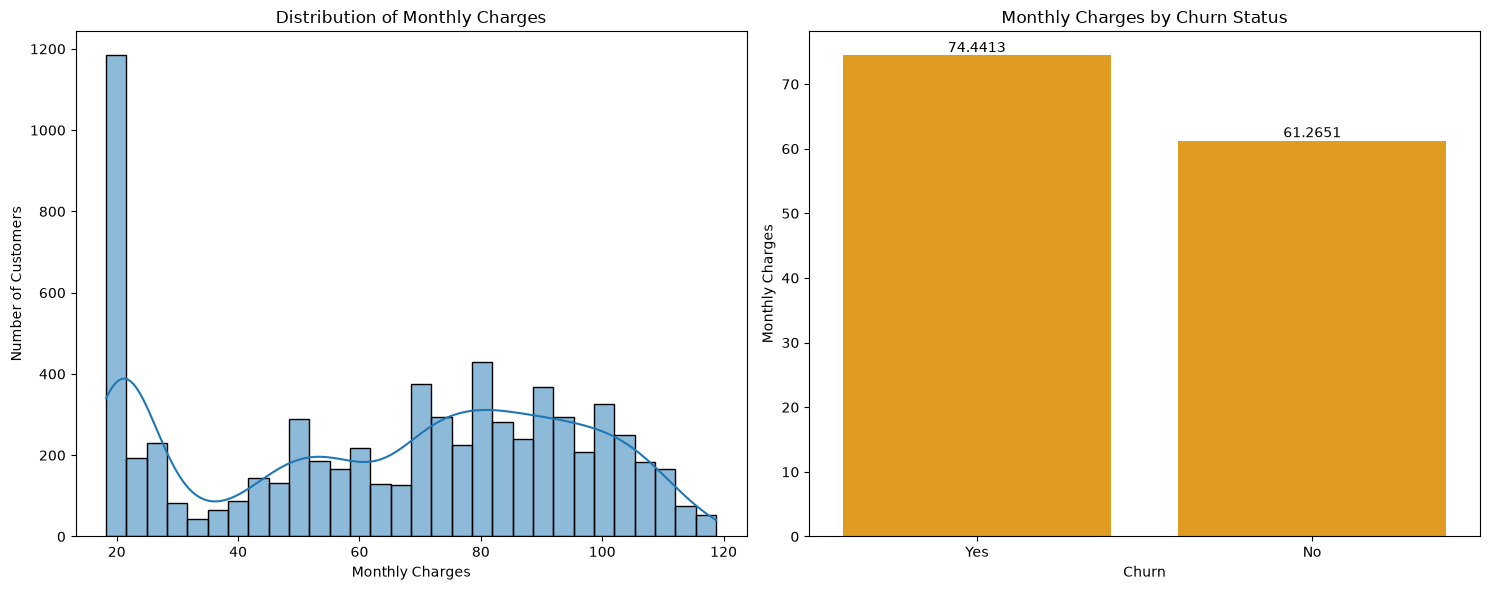

In [32]:
# Create a figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Histogram with KDE ---
ax1 = sns.histplot(
    x = "Monthly Charges",   # Column from your DataFrame to plot
    data = df,               # The DataFrame containing the data
    bins = 30,               # Number of bins (intervals) for the histogram
    kde = True,              # Overlay a Kernel Density Estimate curve
    ax = axes[0]             # Draw it on the first subplot (left side)
)

ax1.set_title("Distribution of Monthly Charges")
ax1.set_xlabel("Monthly Charges")
ax1.set_ylabel("Number of Customers")

# --- Barplot ---
ax2 = sns.barplot(
    x = "Churn Label",
    y = "Monthly Charges",
    data = df,
    color = "Orange",
    errorbar=None,
    ax = axes[1]
)

for bars in ax2.containers:
    ax2.bar_label(bars)

ax2.set_title("Monthly Charges by Churn Status")
ax2.set_xlabel("Churn")
ax2.set_ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

Conclusion: Churned customers pay considerably more per month.

Distribution of Total Charges & Total Charges by Churn Status
-

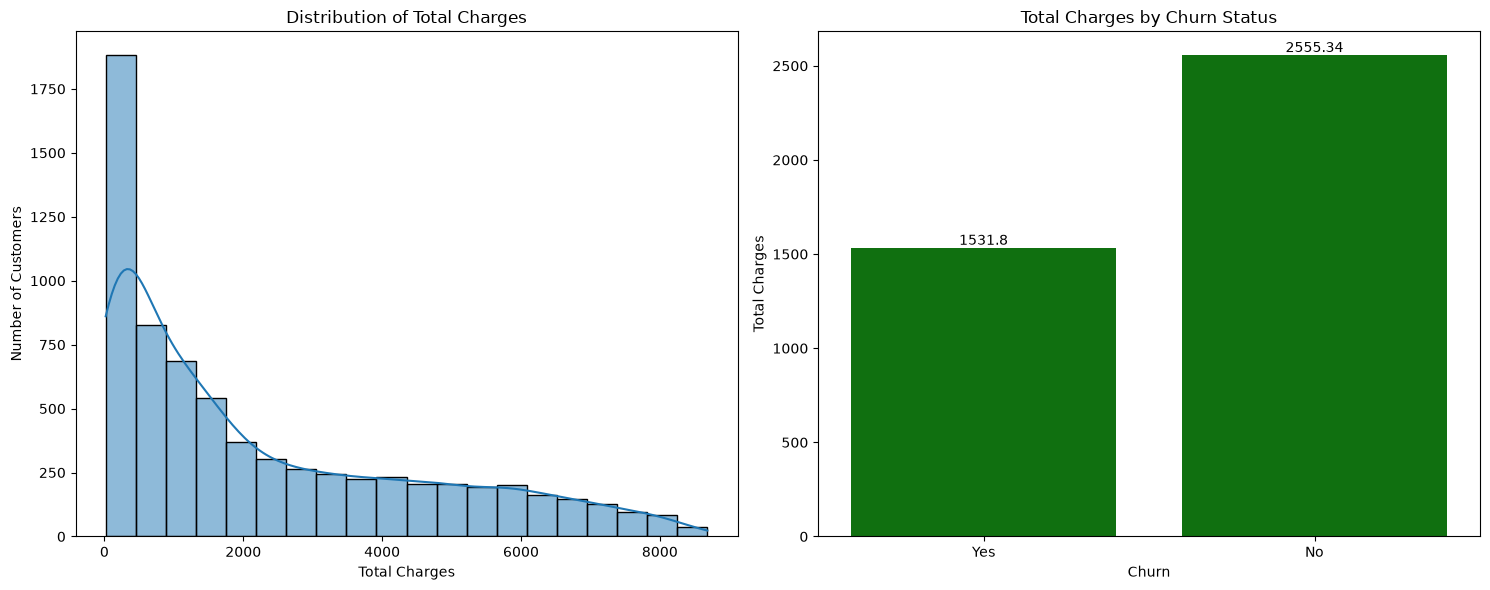

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -- Histplot with KDE ---
ax1 = sns.histplot(
    x = "Total Charges",
    data = df,
    bins = 20,
    kde = True,
    ax = axes[0]
)

ax1.set_title("Distribution of Total Charges")
ax1.set_xlabel("Total Charges")
ax1.set_ylabel("Number of Customers")

# --- Barplot ---
ax2 = sns.barplot(
    x = "Churn Label",
    y = "Total Charges",
    data = df,
    color = "Green",
    errorbar=None,
    ax = axes[1]
)

ax2.set_title("Total Charges by Churn Status")
ax2.set_xlabel("Churn")
ax2.set_ylabel("Total Charges")

for bars in ax2.containers:
    ax2.bar_label(bars)

plt.tight_layout()
plt.show()

Conclusion: Churners have lower total charges.

CATEGORICAL EDA
-

In [72]:
''' Function to Calculate Churn Rate for All Categorical Columns '''
def churn_rate_by_category(df, column):
    churn_rate = (
        df.groupby(column)['Churn Label'].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)
    )
    
    return churn_rate

Contract vs Churn
-

In [36]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [66]:
# Calculating Contract Churn Percentage
contract_churn = churn_rate_by_category(df, 'Contract')
print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Label, dtype: float64


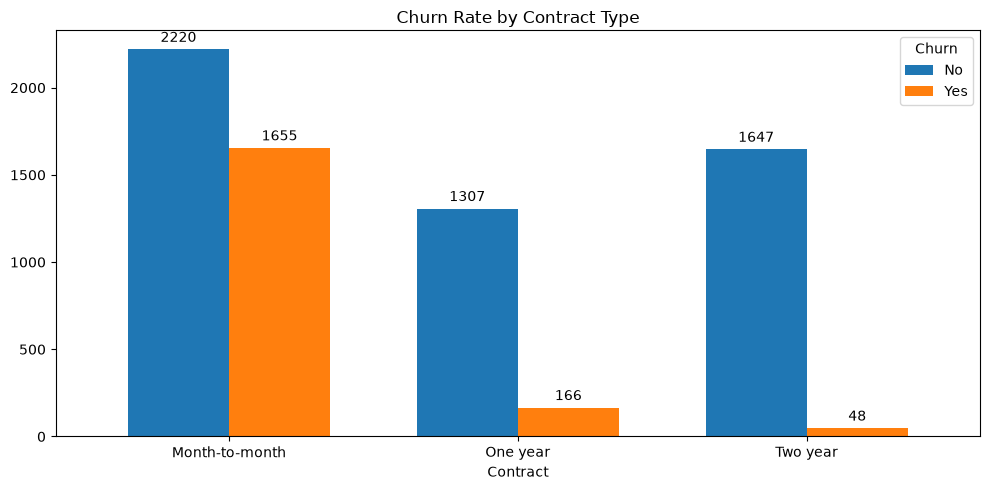

In [60]:
counts = df.groupby(['Contract', 'Churn Label']).size().unstack()

ax = counts.plot(
    kind = 'bar',
    figsize = (10, 5),
    width = 0.7,
)

ax.set_title("Churn Rate by Contract Type")
ax.legend(title = 'Churn')

for bars in ax.containers:
    ax.bar_label(bars, padding=3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Conclusion: Month-to-month customers are the highest-risk group.

Internet Service vs Churn
-

In [16]:
df['Internet Service'] = df['Internet Service'].replace('No', 'No internet')

# Calculating Churn rate by Internet Service
internet_churn = churn_rate_by_category(df, 'Internet Service')
print(internet_churn)

Internet Service
Fiber optic    41.892765
DSL            18.959108
No internet     7.404980
Name: Churn Label, dtype: float64


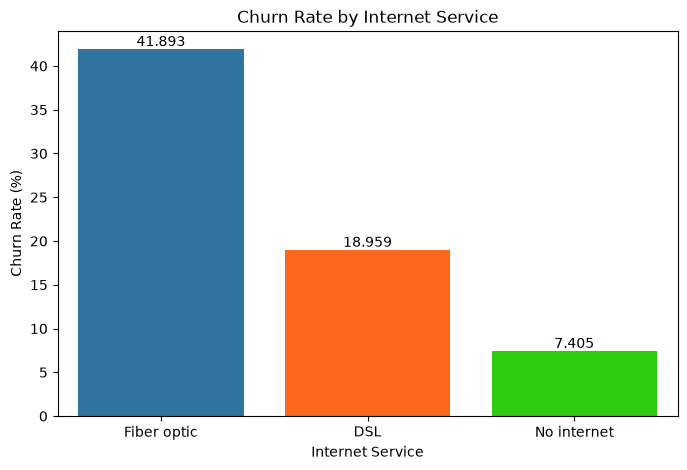

In [17]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x = internet_churn.index,
    y = internet_churn.values
)

ax.patches[1].set_facecolor("#ff6721")
ax.patches[2].set_facecolor("#2ecc0e")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for bars in ax.containers:
    ax.bar_label(bars, fmt="%.3f")

plt.show()

Conclusion: Fiber customers have an unexpectedly high churn rate.

Payment Method vs Churn
-

In [18]:
# Calculating Churn Rate by Payment Method
payment_churn = churn_rate_by_category(df, 'Payment Method')
print(payment_churn)

Payment Method
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn Label, dtype: float64


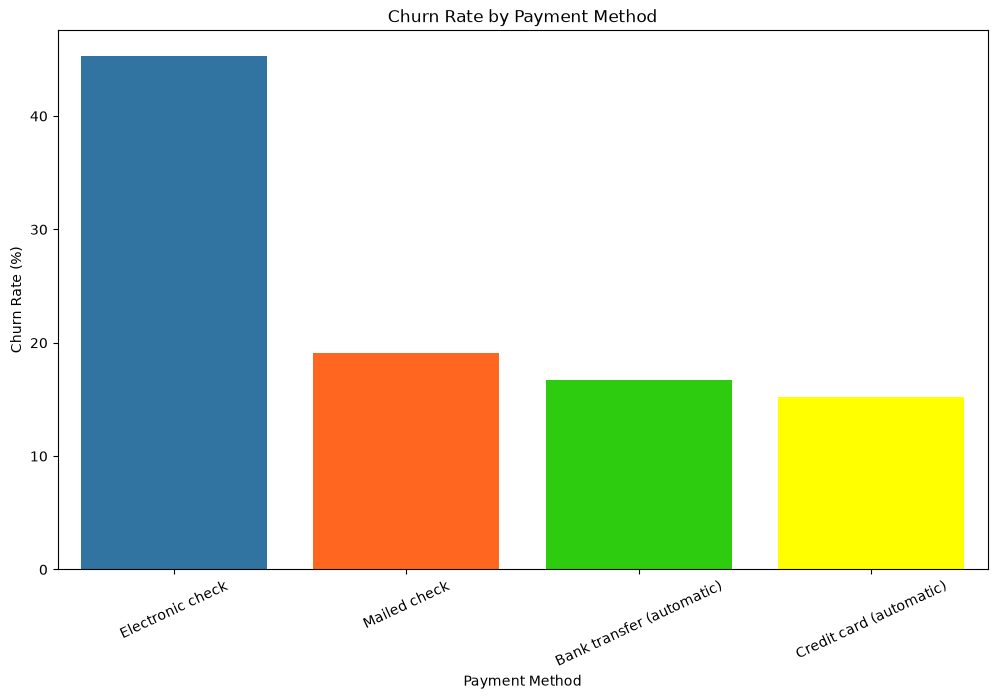

In [22]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x = payment_churn.index,
    y = payment_churn.values
)

ax.patches[1].set_facecolor("#ff6721")
ax.patches[2].set_facecolor("#2ecc0e")
ax.patches[3].set_facecolor("yellow")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=25)

plt.show()

Conclusion: Electronic-check customers are a very high-risk segment

Tech Support vs Churn
-

In [5]:
# Calculating Churn Rate by Tech Support
tech_churn = churn_rate_by_category(df, 'Tech Support')
print(tech_churn)

Tech Support
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Churn Label, dtype: float64


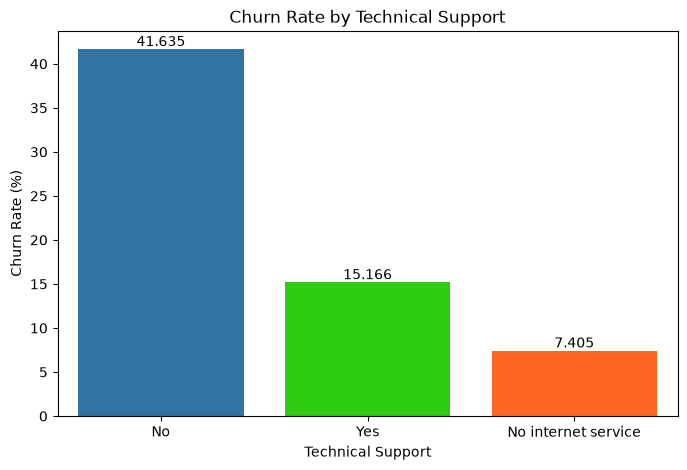

In [21]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x = tech_churn.index,
    y = tech_churn.values
)

plt.title("Churn Rate by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Churn Rate (%)")

ax.patches[1].set_facecolor('#2ecc0e')
ax.patches[2].set_facecolor('#ff6721')

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.3f')

plt.show()

Conclusion: Customers without technical support have substantially higher churn.

Gender vs Churn
-

In [23]:
# Calculating Churn Rate by Gender
gender_churn = churn_rate_by_category(df, 'Gender')
print(gender_churn)

Gender
Female    26.920872
Male      26.160338
Name: Churn Label, dtype: float64


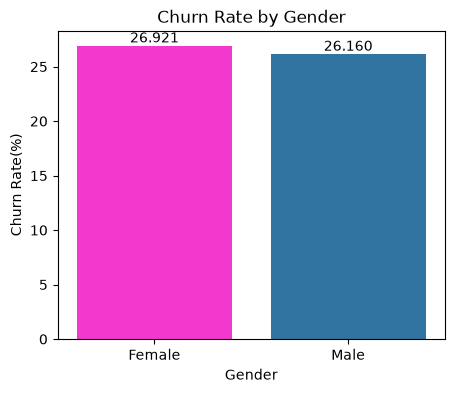

In [28]:
plt.figure(figsize=(5, 4))

ax = sns.barplot(
    x = gender_churn.index,
    y = gender_churn.values
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate(%)")

ax.patches[0].set_facecolor('#f238cd')

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.3f')

plt.show()

Dependents vs Churn
-

In [34]:
dependent_churn = churn_rate_by_category(df, 'Dependents')
print(dependent_churn)

Dependents
No     32.551699
Yes     6.515058
Name: Churn Label, dtype: float64


Partner vs Churn
-

In [35]:
partner_churn = churn_rate_by_category(df, 'Partner')
print(partner_churn)

Partner
No     32.957979
Yes    19.664903
Name: Churn Label, dtype: float64


Senior Citizen vs Churn
-

In [36]:
senior_churn = churn_rate_by_category(df, 'Senior Citizen')
print(senior_churn)

Senior Citizen
Yes    41.681261
No     23.606168
Name: Churn Label, dtype: float64


Categorical Data Summary
-

In [38]:
categorical_cols = [
    "Gender",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

for col in categorical_cols:
    print("\n" + '=' * 50)
    print(churn_rate_by_category(df, col))


Gender
Female    26.920872
Male      26.160338
Name: Churn Label, dtype: float64

Partner
No     32.957979
Yes    19.664903
Name: Churn Label, dtype: float64

Dependents
No     32.551699
Yes     6.515058
Name: Churn Label, dtype: float64

Phone Service
Yes    26.709637
No     24.926686
Name: Churn Label, dtype: float64

Multiple Lines
Yes                 28.609896
No                  25.044248
No phone service    24.926686
Name: Churn Label, dtype: float64

Internet Service
Fiber optic    41.892765
DSL            18.959108
No internet     7.404980
Name: Churn Label, dtype: float64

Online Security
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Churn Label, dtype: float64

Online Backup
No                     39.928756
Yes                    21.531494
No internet service     7.404980
Name: Churn Label, dtype: float64

Device Protection
No                     39.127625
Yes                    22.502064
No internet service     7.40

Churn Rate Summary Table
-

In [42]:
summary = []

for col in categorical_cols:
    rates = churn_rate_by_category(df, col)

    for category, rate in rates.items():
        summary.append({
            "Feature": col,
            "Category": category,
            "Churn Rate(%)": round(rate, 2)
        })

churn_summary = pd.DataFrame(summary)
churn_summary

,Feature,Category,Churn Rate(%)
0,Gender,Female,26.92
1,Gender,Male,26.16
2,Partner,No,32.96
3,Partner,Yes,19.66
4,Dependents,No,32.55
5,Dependents,Yes,6.52
6,Phone Service,Yes,26.71
7,Phone Service,No,24.93
8,Multiple Lines,Yes,28.61
9,Multiple Lines,No,25.04


Correlation Analysis: Correlation is mainly useful for numerical variables.
-

In [79]:
numeric_cols = [
    "Senior Citizen",
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

df["Churn Binary"] = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

corr = df[numeric_cols + ['Churn Binary']].corr()
print(corr)

                 Senior Citizen  Tenure Months  Monthly Charges  \
Senior Citizen         1.000000       0.016567         0.220173   
Tenure Months          0.016567       1.000000         0.247900   
Monthly Charges        0.220173       0.247900         1.000000   
Total Charges          0.102411       0.825880         0.651065   
Churn Binary           0.150889      -0.352229         0.193356   

                 Total Charges  Churn Binary  
Senior Citizen        0.102411      0.150889  
Tenure Months         0.825880     -0.352229  
Monthly Charges       0.651065      0.193356  
Total Charges         1.000000     -0.199484  
Churn Binary         -0.199484      1.000000  


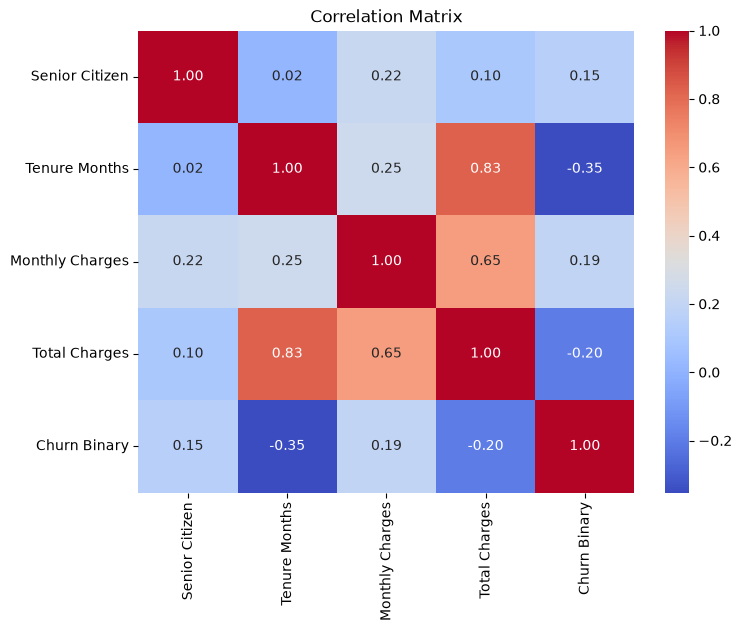

In [82]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr, # Uses Seaborn to plot your correlation matrix (corr) as a heatmap.
    annot = True, # Displays the actual correlation values inside each cell.
    cmap = 'coolwarm', # Sets the color scheme
    fmt = '.2f'
)

plt.title("Correlation Matrix")
plt.show()

Correlation indicates the strength and direction of association.

Outlier Analysis
-

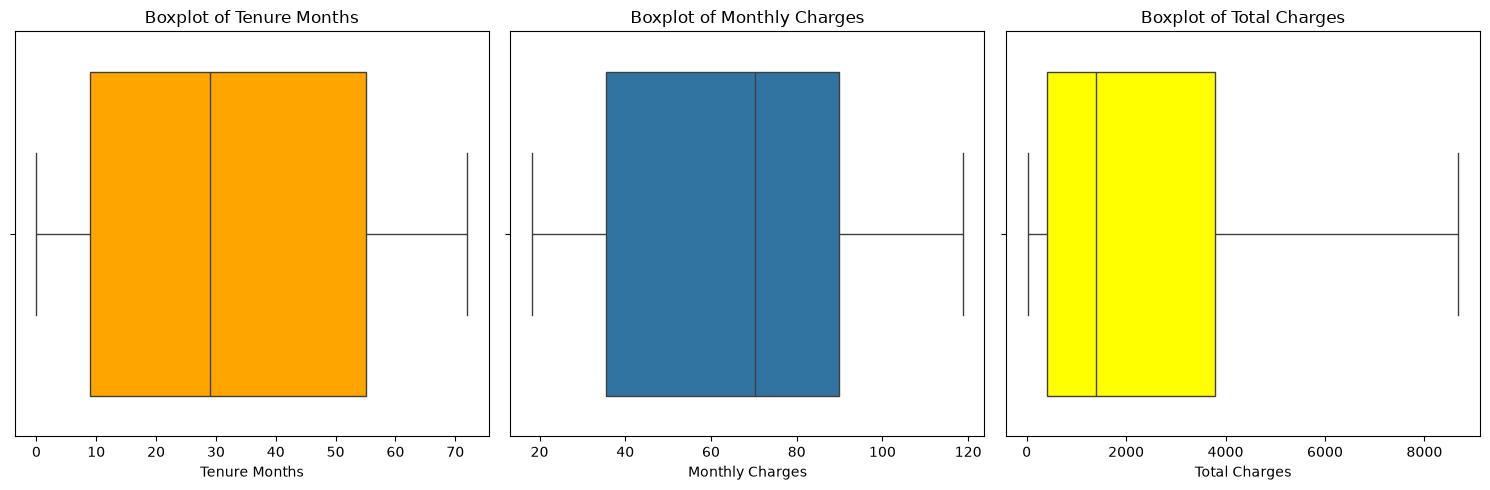

In [91]:
numeric_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Tenure Months ---
ax1 = sns.boxplot(
    x = 'Tenure Months',
    data = df,
    ax = axes[0]
)

ax1.patches[0].set_facecolor("Orange")
ax1.set_title("Boxplot of Tenure Months")
ax1.set_xlabel("Tenure Months")

# --- Monthly Charges ---
ax2 = sns.boxplot(
    x = 'Monthly Charges',
    data = df,
    ax = axes[1]
)

ax2.set_title("Boxplot of Monthly Charges")
ax2.set_xlabel("Monthly Charges")

# --- Total Charges ---
ax3 = sns.boxplot(
    x = 'Total Charges',
    data = df,
    ax = axes[2]
)

ax3.patches[0].set_facecolor("Yellow")
ax3.set_title("Boxplot of Total Charges")
ax3.set_xlabel("Total Charges")

plt.tight_layout()
plt.show()

Service Count Feature
-

In [102]:
service_cols = [
    "Phone Service",
    "Multiple Lines",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

df['Service Count'] = df[service_cols].apply(lambda x: (x == "Yes").sum(), axis=1)

In [107]:
# Calculating Churn Rate by Service Count
service_churn = churn_rate_by_category(df, 'Service Count')
print(service_churn)

Service Count
0    43.750000
3    36.476684
2    32.828283
4    31.344902
5    25.550661
6    22.485207
1    21.105232
7    12.405063
8     5.288462
Name: Churn Label, dtype: float64


OVERALL EDA INSIGHT
-

The overall story of the Telco customer dataset is quite clear:
Customer churn is mainly concentrated among newer, month-to-month customers who have higher monthly charges and certain service/payment characteristics.

🔴 1. Churn is a significant business problem
Overall churn is approximately 26.5%.
So roughly 1 out of every 4 customers has churned.
This indicates that customer retention should be a major business priority.

🔴 2. New customers are the biggest risk
Customers with 0–6 months tenure have churn of roughly 53%.
Customers with 61–72 months tenure have churn of only around 7%.
Churn decreases substantially as customer tenure increases.
Business insight: The company should focus retention efforts heavily during the first 6–12 months.

🔴 3. Contract type is one of the strongest indicators
Approximate churn rates:
Contract	Churn
Month-to-month	42.7%
One year	11.3%
Two year	2.8%
Customers on month-to-month contracts are dramatically more likely to leave.
Business action: Encourage customers to move toward longer-term contracts through discounts, loyalty benefits, or service bundles.

🔴 4. Higher monthly charges are associated with churn
Average monthly charges are approximately:
Churned: $74.44
Stayed: $61.27
So churned customers tend to have higher monthly bills.
However, we shouldn't conclude that price alone causes churn. Higher charges may be connected with other factors such as internet service and contract type.

🔴 5. Fiber-optic customers require investigation
Approximate churn:
Fiber optic → 41.9%
DSL → 19.0%
No internet → 7.4%
This is an interesting business anomaly.
Question for the company: Why are fiber customers leaving at such a high rate?
Potential areas to investigate:
Pricing
Service quality
Technical problems
Competition
Customer support
Contract structure

🔴 6. Payment method shows a strong difference
Electronic-check customers have churn of roughly 45%, considerably higher than other payment groups.
This doesn't mean electronic checks cause churn, but it identifies a high-risk customer segment worth investigating.

🔴 7. Support and security services are associated with retention
Customers without services such as:
Technical Support
Online Security
Online Backup
tend to have substantially higher churn.
For example, customers without Tech Support have churn around 42%, compared with about 15% among those with support.
Business insight: Better service engagement and proactive support may help retention.

🔴 8. Customer engagement appears important
Our Service Count analysis suggests customers using more services generally have lower churn.
For example:
Customers using 8 services had churn around 5%, while customers with no services had churn around 44%.
This suggests that bundling and deeper customer engagement may improve retention.

In [120]:
df.to_excel("cleaned_telco_customer_churn.xlsx", index=False)